# C. Emissions wIHS

**Overview.** Computes activity-based emissions for vessels that were matched to the IHS register. It joins the hourly AIS panel (notebook A) with the per-vessel specs/factors (notebook B), reconstructs each vessel's operating state per hour — speed over ground cleaned against max speed, instantaneous draught, and an operational phase (At Berth / Anchored / Manoeuvring / Sea) — derives main-engine load and power demand, and applies the IMO bottom-up formulas to produce per-hour emissions of CO₂, SOx, NOx, CH₄, CO, N₂O, NMVOC, PM10, PM2.5, and black carbon (main engine + pilot fuel + auxiliary engine + boiler). Fishing activity is flagged via a Global Fishing Watch join. Restricted to positions inside a country EEZ.

**Series.** Notebook **C** of the five-part series (A–E) estimating ship emissions in Pacific Island EEZs per the Fourth IMO GHG Study 2020:
- **A. AIS Data Prep** — hourly vessel-position panel tagged with EEZ/coast/port and IHS vessel IDs
- **B. IHS Specs** — per-vessel specs, correction factors, and emission factors
- **C. Emissions wIHS** — activity-based emissions for IHS-matched vessels *(this notebook)*
- **D. Emissions woIHS** — emissions for vessels without an IHS match, via a median-per-type model derived from this notebook's output
- **E. Emissions Statistics** — monthly country / vessel-type / fishing aggregations and dashboard CSVs

**Inputs.**
- Hourly AIS parquet from A: `…/emissions/Pacific/hourly_ais_v2/` (read by `year`/`month` partition).
- IHS specs parquet from B: `…/emissions/Pacific/ihs_emissions_specs {ihs_version}.parquet` (`ihs_version = "20260202"`).
- Global Fishing Watch effort: `…/worldbank/GFW_effort_event/{year}.csv` (used to flag fishing hours).
- Platform S3 root `"s3a://" + os.environ["AWS_WORKING_DIRECTORY_PATH"] + "worldbank/"`.

**Output.** Per-hour emissions parquet partitioned by `year`/`month`/`Country` at `…/emissions/Pacific/emissions_data/with_ihs/`. Each pollutant has an `_e`/`_f` per-hour column and a `…_xhour` column scaled by the time gap to the next position. A `…/temp/` parquet is used as an intermediate staging area within each monthly run.

**Requirements.**
- Runs on the **UN Global Platform** — account required: https://datalab.officialstatistics.org
- PySpark cluster with the platform `ais` library; uses Spark window functions for next-position lookups and dynamic partition overwrite (`spark.sql.sources.partitionOverwriteMode=dynamic`) so monthly re-runs replace only the affected partitions.
- Country sub-regions of Kiribati (Phoenix/Gilbert/Line groups) are collapsed into `Kiribati`.

# Initialize - Pacific

_Imports, Spark session, and path/IHS-version configuration._


In [1]:
import pandas as pd

pd.set_option('display.max_columns', None) #Show all columns in pandas df
pd.set_option('display.max_rows', 100) #Show all columns in pandas df
#silent future warnings
# pd.set_option('future.no_silent_downcasting', True)
pd.options.display.float_format = "{:,.2f}".format

from IPython.core.interactiveshell import InteractiveShell #allow multiple outputs in one jupyter cell
InteractiveShell.ast_node_interactivity = "all"

In [2]:
from pyspark.sql import SparkSession
from pyspark.sql.types import *
from pyspark.sql import functions as F

spark = SparkSession.builder.getOrCreate()


In [3]:
from ais import functions as af

In [4]:
from pyspark.sql import functions as F
from pyspark.sql import Window as W
from pyspark.sql import types as t

In [5]:
import numpy as np
from dateutil.relativedelta import relativedelta

In [6]:
import os
wb_path = "s3a://" + os.environ["AWS_WORKING_DIRECTORY_PATH"] + "worldbank/"
project_path = wb_path + "emissions/Pacific/"

In [7]:
ihs_version = "20260202"
ais_base_path = project_path+"hourly_ais_v2/"

# Start

_Loads the hourly AIS panel and lists the IHS spec columns to attach._


In [8]:
ais_base_path = project_path+"hourly_ais_v2/"

In [9]:
sdf = spark.read.parquet(ais_base_path)

In [10]:
ihs_columns = ['LRIMOShipNo','ShipName','ExName',
'_w_boiler',
 '_w_aux',
 '_vessel_class_no',
 '_vessel_group',
 '_vessel_class',
 '_beam',
 '_beam_basis',
 '_draught_basis',
 '_draught',
 '_length',
 '_length_basis',
 '_deadweight_basis',
 '_deadweight',
 '_grosstonnage_basis',
 '_grosstonnage',
 '_teu_basis',
 '_teu',
 '_gascapacity_basis',
 '_gascapacity',
 '_size_unit',
 '_size_bin',
 '_capacity',
 '_size_bin_basis',
 '_me_rpm',
 '_me_rpm_basis',
 '_speed',
 '_speed_basis',
 '_me_power',
 '_me_power_basis',
 '_me_fuel_type',
 '_me_fuel_type_basis',
 '_me_type',
 '_me_type_basis',
 '_me_power_weather_cf',
 '_me_power_fouling_cf',
 '_speed_cf',
 '_eng_gen',
 '_me_sfcb',
 '_ae_sfcb',
 '_ab_sfcb',
 '_me_sfcb_pilot',
 '_ab_berth',
 '_ab_anch',
 '_ab_man',
 '_ab_sea',
 '_ae_berth',
 '_ae_anch',
 '_ae_man',
 '_ae_sea',
 '_bc_ee_f',
 '_ab_bc_ee_f',
 '_ae_bc_ee_f',
 '_ab_bc_ef_f',
 '_ae_bc_ef_f',
 '_me_stroke_type',
 '_me_stroke_type_basis',
 '_ae_pm10_ee_f',
 '_ae_pm25_ee_f',
 '_ab_pm10_ee_f',
 '_ab_pm25_ee_f',
 '_co2_ef_f',
 '_sox_ef_f',
 '_ab_co2_ef_f',
 '_ae_co2_ef_f',
 '_ab_sox_ef_f',
 '_ae_sox_ef_f',
 '_nox_tier',
 '_rpm_bin',
 '_nox_ee_f',
 '_ab_nox_ee_f',
 '_ae_nox_ee_f',
 '_ch4_ee_f',
 '_co_ee_f',
 '_n2o_ee_f',
 '_nmvoc_ee_f',
 '_ab_ch4_ee_f',
 '_ab_co_ee_f',
 '_ab_n2o_ee_f',
 '_ab_nmvoc_ee_f',
 '_ae_ch4_ee_f',
 '_ae_co_ee_f',
 '_ae_n2o_ee_f',
 '_ae_nmvoc_ee_f',
 '_co2_ef_f_pilot',
 '_sox_ef_f_pilot',
 '_nox_ee_f_pilot',
 '_ch4_ee_f_pilot',
 '_co_ee_f_pilot',
 '_n2o_ee_f_pilot',
 '_nmvoc_ee_f_pilot',
 '_bc_ee_f_pilot']

# Calculated Columns

_Section defining the per-hour emissions calculation._


## ME Load

From IMO

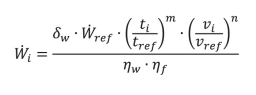

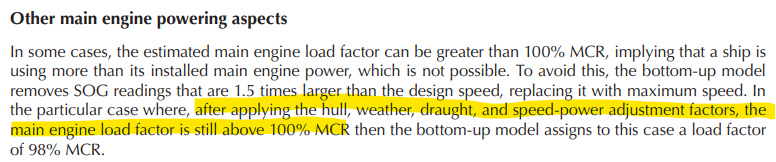

However, from Gabriel

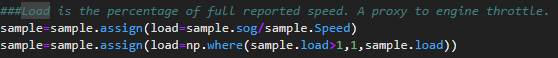

## functions 

_Defines `ais_ihs_prep` (join AIS + IHS + GFW, derive next-position columns, split into IHS-matched vs unmatched) and `calculated_columns` (engine load, power demand, low-load factors, and every per-pollutant emission)._


In [11]:
me_load = F.expr("""_speed_cf*POW(_sog/_speed_max, 3)*POW(_draught / _draught_design, 2/3)/_me_power_weather_cf/_me_power_fouling_cf""")
me_load_cf = F.expr("0.455 * POW(_me_load,2) - 0.719 * _me_load + 1.280")
llf_cols = ['_pm10_llf','_pm25_llf','_nox_llf','_sox_llf','_co2_llf','_co_llf','_ch4_llf','_n2o_llf','_nmvoc_llf','_bc_llf']
fuel_sulphur_fraction_hfo = 0.026
fuel_sulphur_fraction_mdo = 0.0007
ghg_energy = ['_ch4', '_co','_n2o','_nmvoc', '_pm10', '_pm25', '_nox','_bc']
ghg_fuel = ['_co2','_sox','_bc']
me_type_no_ghg = ["Sail","Batteries","Non-Propelled"]

def aux_cols(x):
    if x == "ab":
        cond = "_w_boiler"
    else:
        cond = "_w_aux"
    aux_cols_dict = \
    {f'_{x}_power_per_op': F.when(F.col("_op_phase")=="At Berth", F.col(f"_{x}_berth")) \
                 .when(F.col("_op_phase")=="Anchored", F.col(f"_{x}_anch")) \
                 .when(F.col("_op_phase")=="Manoeuvring", F.col(f"_{x}_man")) \
                 .when(F.col("_op_phase")=="Sea", F.col(f"_{x}_sea"))
    } | {
        f'_{x}_power':F.when(F.col("_me_power_demand").between(0,150), 0) \
                 .when(F.col("_me_power_demand").between(150,500) & F.lit(x == "ab") , F.col(f'_{x}_power_per_op')) \
                 .when(F.col("_me_power_demand").between(150,500) & F.lit(x != "ab"), 0.05 * F.col("_me_power")) \
                 .otherwise(F.col(f'_{x}_power_per_op'))
    } | {
        f"_{x}{ghg}_energy": F.when(~F.col("_me_type").isin(me_type_no_ghg) & F.col(cond), F.expr(f"_{x}{ghg}_ee_f * _{x}_power")).otherwise(0) for ghg in ghg_energy
    } | {f"_{x}{ghg}_fuel": F.when(~F.col("_me_type").isin(me_type_no_ghg) & F.col(cond), F.expr(f"_{x}{ghg}_ef_f * _{x}_power *  _{x}_sfcb")).otherwise(0) for ghg in ghg_fuel
    }
    return aux_cols_dict
        

def calculated_columns(ais):

    ais_factors = ais.withColumns({
    '_hour_diff': (F.col('datetime_next').cast(t.LongType()) -F.col('datetime').cast(t.LongType())) / 3600,
    '_time_multiplier':F.when(F.col("_hour_diff") > 24,24) \
                        .when(F.col("_hour_diff") > 1,F.round(F.col("_hour_diff"),0)) \
                        .otherwise(1),
    '_sog_l_clean':F.when(F.col("sog_l") < F.col("_speed_max")*1.5,F.col("sog_l")),
    '_sog_f_clean':F.when(F.col("sog_f") < F.col("_speed_max")*1.5,F.col("sog_f")),     
    '_sog_l_next_clean':F.when(F.col("sog_l_next") < F.col("_speed_max")*1.5,F.col("sog_l_next")),
    '_sog_f_next_clean':F.when(F.col("sog_f_next") < F.col("_speed_max")*1.5,F.col("sog_f_next")),  
    '_sog': F.coalesce("_sog_f_clean","_sog_l_clean","_sog_f_next_clean","_sog_l_next_clean", "_speed_max"),
    '_draught':F.when((F.col("draught_bfill") > F.col("_draught_design")) & F.col("_draught_design").isNotNull(), F.col("_draught_design")) \
                .when(F.col("draught_bfill").isNotNull(), F.col("draught_bfill")) \
                .when(F.col("draught_bfill").isNull() & F.col("_draught_design").isNotNull(), F.col("_draught_design")) \
                .otherwise(0),
    '_op_phase':F.when(F.col("_sog").isNull(), None) \
                 .when((F.col("_sog") <=1) & F.col("port_flag"), "At Berth") \
                 .when(F.col("_sog") <=3, "Anchored") \
                 .when(F.col("_sog").between(3,5) & (F.col("port_flag") | F.col("coast_flag")),"Manoeuvring") \
                 .otherwise("Sea"),
    '_me_load':F.when( (F.col("_sog")==0) | (F.col("_draught") == 0), 0).otherwise(F.least(F.lit(0.98), me_load)),
    '_me_power_demand':F.expr('_me_power * _me_load'),
    '_me_load_cf':F.when(F.col('_me_type').isin(["SSD","HSD","MSD","LNG-Otto SS","LNG-Otto MS","LNG-Diesel", "LBSI","Methanol SS","Methanol MS"]), 
                         me_load_cf) \
                   .when(F.col('_me_type').isin(["Sail","Steam Turbine","Batteries","Gas Turbine","Non-Propelled"]),1),
    '_me_sfc':F.expr("_me_sfcb * _me_load_cf"),
    '_me_sfc_pilot': F.expr("_me_sfcb_pilot * _me_load_cf"), 
    '_pm10_ee_f': F.when(F.col("_me_type")=="LNG-Diesel", 0.01) \
                   .when(F.col("_me_type").isin(["LNG-Otto SS","LNG-Otto MS","LBSI"]), 0.02) \
                   .when(F.col("_me_type").isin(["Gas Turbine","Steam Turbine"]), 0.03) \
                   .when(F.col('_me_fuel_type')=="HFO", F.expr(f"1.35 + _me_sfc * 7 * 0.02247 * ({fuel_sulphur_fraction_hfo} - 0.0246)")) \
                   .when(F.col("_me_fuel_type")=="MDO", F.expr(f"0.23 + _me_sfc * 7 * 0.02247 * ({fuel_sulphur_fraction_mdo} - 0.0024)")) \
                   .when(F.col("_me_fuel_type")=="Methanol",0),
    '_pm25_ee_f': F.col('_pm10_ee_f') * 0.92,
    '_pm10_ee_f_pilot':F.expr(f"0.23 + _me_sfc_pilot * 7 * 0.02247 * ({fuel_sulphur_fraction_mdo} - 0.0024)"),
    '_pm25_ee_f_pilot': F.col("_pm10_ee_f_pilot") * 0.92,
    '_bc_ef_f': F.when((F.col("_me_load")==0) & F.col("_me_fuel_type").isin(["HFO","MDO","Methanol"]),0) \
                 .when((F.col('_me_stroke_type')==2) & (F.col('_me_fuel_type')=='HFO'), 0.00015 *   F.pow(F.col('_me_load'), -0.359)) \
                 .when((F.col('_me_stroke_type')==2) & (F.col('_me_fuel_type')=='MDO'), 0.0000311 * F.pow(F.col('_me_load'), -0.397)) \
                 .when((F.col('_me_stroke_type')==4) & (F.col('_me_fuel_type')=='HFO'), 0.00025 *   F.pow(F.col('_me_load'), -0.968)) \
                 .when((F.col('_me_stroke_type')==4) & (F.col('_me_fuel_type')=='MDO'), 0.0001201 * F.pow(F.col('_me_load'), -1.124)) \
                 .when((F.col('_me_stroke_type')==2) & (F.col('_me_fuel_type')=="Methanol"), 0.00015 *   F.pow(F.col('_me_load'), -0.359) * 0.1) \
                 .when((F.col('_me_stroke_type')==4) & (F.col('_me_fuel_type')=="Methanol"), 0.00025 *   F.pow(F.col('_me_load'), -0.968) * 0.1)
                 .when((F.col("_me_fuel_type") == "LNG"), 0) \
                 .when(F.col("_me_type").isin(["Steam Turbine","Gas Turbine"]), 0.003),
    '_bc_ef_f_pilot': F.when(F.col("_me_load")==0,0) \
                       .when((F.col('_me_stroke_type')==2) , 0.0000311 * F.pow(F.col('_me_load'), -0.397)) \
                       .when((F.col('_me_stroke_type')==4) , 0.0001201 * F.pow(F.col('_me_load'), -1.124)) \
                       .otherwise(0),
    '_llf':F.when((F.col("_me_load") >=0) & (F.col("_me_load") < 0.02), 
                  F.array([F.lit(7.29),F.lit(7.29),F.lit(4.63),F.lit(1),F.lit(1),F.lit(9.7),F.lit(21.18),F.lit(4.63),F.lit(21.18),F.lit(1)])) \
            .when(F.col("_me_load") <0.1, 
                  F.array([F.lit(1.38),F.lit(1.38),F.lit(1.22),F.lit(1),F.lit(1),F.lit(1.97),F.lit(2.18),F.lit(1.22),F.lit(2.18),F.lit(1)])) \
            .when(F.col("_me_load")>=0.1, 
                  F.array([F.lit(1),F.lit(1),F.lit(1),F.lit(1),F.lit(1),F.lit(1),F.lit(1),F.lit(1),F.lit(1), F.lit(1)]))} | {
    llf_cols[i]:F.col("_llf").getItem(i) for i in range(len(llf_cols))} | {
    f"{ghg}_energy": F.when(~F.col("_me_type").isin(me_type_no_ghg), F.expr(f"{ghg}_ee_f * _me_power_demand * {ghg}_llf")).otherwise(0) for ghg in ghg_energy} | {
    f"{ghg}_energy_pilot": F.when(~F.col("_me_type").isin(me_type_no_ghg), F.expr(f"{ghg}_ee_f_pilot * _me_power_demand * {ghg}_llf")).otherwise(0) for ghg in ghg_energy} | {
    f"{ghg}_fuel": F.when(~F.col("_me_type").isin(me_type_no_ghg), F.expr(f"{ghg}_ef_f * _me_power_demand * {ghg}_llf * _me_sfc")).otherwise(0) for ghg in ghg_fuel} | {
    f"{ghg}_fuel_pilot": F.when(~F.col("_me_type").isin(me_type_no_ghg), F.expr(f"{ghg}_ef_f_pilot * _me_power_demand * {ghg}_llf * _me_sfc_pilot")).otherwise(0) for ghg in ghg_fuel} | 
    aux_cols("ab") | aux_cols("ae") | {
    f"{ghg}_e":F.col(f"{ghg}_energy") +  F.col(f"{ghg}_energy_pilot") + F.col(f"_ab{ghg}_energy") + F.col(f"_ae{ghg}_energy") for ghg in ghg_energy} | {
    f"{ghg}_f":F.col(f"{ghg}_fuel") + F.col(f"{ghg}_fuel_pilot") + F.col(f"_ab{ghg}_fuel") + F.col(f"_ae{ghg}_fuel") for ghg in ghg_fuel} |{
    f"{ghg}_e_xhour":F.col(f"{ghg}_e") * F.col("_time_multiplier") for ghg in ghg_energy} | {
    f"{ghg}_f_xhour":F.col(f"{ghg}_f") * F.col("_time_multiplier") for ghg in ghg_fuel}    
    ) 
    return ais_factors

In [12]:
w = W.partitionBy("vessel_id").orderBy("datetime")
w_following = W.partitionBy('vessel_id','Country').orderBy("datetime").rowsBetween(W.currentRow, W.unboundedFollowing) 

def ais_ihs_prep(paths_to_read, ihs,gfw=None):
    ais = ( spark
           .read
           .option("basepath",ais_base_path).parquet(*paths_to_read)
           .select("vessel_id","imo","mmsi","vessel_name","vessel_type","length","width","ISO3","Country","eez_flag","coast_flag","Port_name","port_flag",
                   "year","month", F.expr("to_timestamp(date  || ' ' || hour)").alias("dt_pos_utc"), 'longitude','latitude', "sog_f",
                  "sog_l",
                   F.col('draught_f').alias("draught"),'LRIMOShipNo','ihs_matchtype')
           .withColumnRenamed("Country","Country_sub")
           .withColumn("Country",F.when(F.col("Country_sub").isin(['Phoenix Group','Gilbert Islands','Line Group']),"Kiribati").otherwise(F.col("Country_sub")))
           .withColumn("date",F.to_date("dt_pos_utc"))
           .withColumnRenamed("dt_pos_utc","datetime")
           .withColumns({"eez_flag_next":F.lag("eez_flag",-1).over(w),
                         "datetime_next":F.lag("datetime",-1).over(w),
                         "sog_f_next":F.lag("sog_f",-1).over(w),
                         "sog_l_next":F.lag("sog_l",-1).over(w)
                        })
           .withColumn("draught_nozero", F.col("draught")).replace(0, None, subset=['draught_nozero'])
           .withColumn("draught_bfill", F.first(F.col("draught_nozero"), True).over(w_following))
          )
    if gfw:
        ais_gfw = ais.join(gfw, on=['date','mmsi','Country_sub'], how="left").withColumn("_w_fishing", F.col("fishing_hours").isNotNull())
    else:
        ais_gfw = ais.withColumn("fishing_hours", F.lit(None).cast(DoubleType())).withColumn("_w_fishing", F.lit(False))
        
    w_ihs = ais_gfw.filter(F.col("eez_flag")) \
            .join(ihs, on = ['LRIMOShipNo']) 
    
    wo_ihs = ais_gfw.filter(F.col("eez_flag")) \
            .join(ihs.select("LRIMOShipNo"), on = ['LRIMOShipNo'], how="left_anti") 
    
    return w_ihs, wo_ihs

# Calculate Emissions from IHS

_Loads the IHS specs parquet and prepares the GFW fishing-effort reader._


In [13]:
sdf_vessels= af.read_ihs_table(spark, "ShipData.CSV", version="latest").select("LRIMOShipNo","StatCode5")
sdf_vessels.printSchema()
print(f"unique vessels: {sdf_vessels.count():,}")


root
 |-- LRIMOShipNo: integer (nullable = true)
 |-- StatCode5: string (nullable = true)

unique vessels: 270,153


In [14]:
ihs = spark.read.parquet(f"{project_path}/ihs_emissions_specs {ihs_version}.parquet") \
.select(ihs_columns) \
.withColumnsRenamed({'_draught':'_draught_design',
                 '_draught_basis':'_draught_design_basis',
                 '_speed':'_speed_max',
                 '_speed_basis':'_speed_max_basis',
                 }
       )

In [15]:
ihs.filter(F.col("_w_boiler")).count() #6143

6352

In [16]:
def read_gfw(year):
    gfw = spark.read.option("header",True).csv(f"{wb_path}GFW_effort_event/{year}.csv") \
    .select(F.col("mmsi").cast(IntegerType()),
            F.col("Country").alias("Country_sub"),
            F.col("hours").alias("fishing_hours").cast(DoubleType()),
            F.to_date("date").alias("date"))
    
    return gfw

## Run

_Sets Spark to dynamic partition overwrite before writing._


In [17]:
# allow overwrite of partiion only
spark.conf.set("spark.sql.sources.partitionOverwriteMode", "dynamic")
spark.conf.set("spark.sql.parquet.output.committer.class",
               "org.apache.parquet.hadoop.ParquetOutputCommitter")
spark.conf.set("spark.sql.sources.commitProtocolClass",
               "org.apache.spark.sql.execution.datasources.SQLHadoopMapReduceCommitProtocol")

## first run

_Initial run for the seed months (mode=overwrite), with sanity-check totals by country._


In [31]:
gfw = read_gfw(2024)

In [19]:
mode="overwrite"
paths_to_read = [ais_base_path+f"year=2024/month=9", ais_base_path+f"year=2024/month=10"]

w_ihs, wo_ihs = ais_ihs_prep(paths_to_read, ihs, gfw)
ais_factors = calculated_columns(w_ihs.filter((F.col("year")==2024) & (F.col("month")==9)))

In [20]:
ais_factors.write.mode("overwrite").parquet(f"{project_path}temp/")

In [21]:
sdf = spark.read.parquet(f"{project_path}temp/")

In [22]:
ghg = [x for x in sdf.columns if "_xhour" in x]
ghg

['_ch4_e_xhour',
 '_co_e_xhour',
 '_n2o_e_xhour',
 '_nmvoc_e_xhour',
 '_pm10_e_xhour',
 '_pm25_e_xhour',
 '_nox_e_xhour',
 '_bc_e_xhour',
 '_co2_f_xhour',
 '_sox_f_xhour',
 '_bc_f_xhour']

In [23]:
df = sdf.groupBy("Country").agg(*[F.sum(x).alias(x) for x in ghg]).toPandas()

In [24]:
df.sort_values('Country', inplace=True)
df

,Country,_ch4_e_xhour,_co_e_xhour,_n2o_e_xhour,_nmvoc_e_xhour,_pm10_e_xhour,_pm25_e_xhour,_nox_e_xhour,_bc_e_xhour,_co2_f_xhour,_sox_f_xhour,_bc_f_xhour
9,Cook Islands,"333,501.21","9,851,918.33","1,009,734.34","20,331,192.07","23,752,584.25","21,852,377.51","463,060,088.46",0.00,"10,011,358,635.84","135,095,194.05","1,400,350.64"
3,Fiji,"381,446.71","11,167,207.47","1,144,890.45","22,918,676.11","26,127,427.76","24,037,233.54","513,805,830.88",0.00,"11,398,633,933.49","148,509,643.51","3,324,156.85"
1,Kiribati,"811,025.36","23,344,401.89","2,458,151.51","49,246,173.07","53,584,633.29","49,297,862.63","1,129,579,783.18",0.00,"24,446,346,156.75","299,587,763.33","4,036,786.22"
5,Marshall Islands,"811,178.67","12,039,797.60","1,282,126.49","25,393,197.24","25,959,083.84","23,882,357.13","567,272,069.44","1,270.91","12,808,348,865.67","140,832,919.39","1,551,974.05"
12,Micronesia,"96,131,786.09","181,593,465.29","15,976,713.46","323,962,426.30","368,552,839.63","339,068,612.46","7,241,191,199.09","130,965.59","156,999,174,090.85","2,089,169,594.14","10,323,574.04"
7,Nauru,"86,798.50","2,435,131.51","257,541.15","5,224,042.64","4,988,681.22","4,589,586.72","111,369,519.62",0.00,"2,536,261,146.82","25,821,068.54","463,204.70"
14,Niue,"38,717.69","1,183,493.83","120,621.82","2,366,687.37","3,222,660.57","2,964,847.73","54,116,301.98",0.00,"1,180,639,959.60","18,938,413.63","99,921.17"
4,Palau,"39,223,638.39","52,565,677.14","4,135,386.83","84,759,048.08","92,860,782.58","85,431,919.97","1,843,308,556.44","47,254.49","40,456,860,266.39","528,715,277.34","2,955,088.94"
10,Papua New Guinea,"280,880,479.48","470,700,387.97","39,722,129.51","812,279,218.26","915,587,991.88","842,340,952.53","17,927,661,791.61","354,235.16","390,249,520,443.74","5,198,803,194.99","31,432,138.75"
8,Samoa,"29,088.78","807,811.00","81,228.99","1,735,252.62","1,617,885.42","1,488,454.58","33,244,482.69",0.00,"787,722,598.98","8,189,710.71","375,411.17"


In [25]:
sdf.filter(F.col("_sog_f_clean").isNull()).select("sog_f","sog_l","sog_l_next","sog_f_next","_sog","_sog_f_next_clean","_sog_l_next_clean","_sog_f_clean","_sog_l_clean","_speed_max").show()

+-----+-----+----------+----------+------------------+-----------------+-----------------+------------+------------+------------------+
|sog_f|sog_l|sog_l_next|sog_f_next|              _sog|_sog_f_next_clean|_sog_l_next_clean|_sog_f_clean|_sog_l_clean|        _speed_max|
+-----+-----+----------+----------+------------------+-----------------+-----------------+------------+------------+------------------+
| 37.0| 37.0|       1.0|      20.0|              20.0|             20.0|              1.0|        NULL|        NULL|13.652449589894948|
| 47.0| 47.0|      43.0|      38.0|13.652449589894948|             NULL|             NULL|        NULL|        NULL|13.652449589894948|
| 23.0| 23.0|      58.0|      59.0|13.652449589894948|             NULL|             NULL|        NULL|        NULL|13.652449589894948|
| 26.0| 26.0|      41.0|      41.0|              12.8|             NULL|             NULL|        NULL|        NULL|              12.8|
| 28.0| 28.0|       0.0|       0.0|             

In [32]:
mode="overwrite"

In [33]:
spark.read.parquet(f"{project_path}temp/").withColumnRenamed("sog_f","sog").select(*cols_fin).repartition(1).write.mode(mode).partitionBy("year","month","Country").parquet(f"{project_path}emissions_data/with_ihs/")

## monthly

_Loops over months, computing and appending with-IHS emissions partitioned by year/month/Country._


In [18]:
cols_fin = spark.read.parquet(f"{project_path}emissions_data/with_ihs/").columns

In [19]:
date_list = pd.date_range("2025-11-01","2026-01-31", freq="M")
date_list

DatetimeIndex(['2025-11-30', '2025-12-31', '2026-01-31'], dtype='datetime64[ns]', freq='M')

In [21]:
gfw = read_gfw(2025)

In [26]:
mode="overwrite"
for date in date_list[:-1]:
    print(date)
    next_date = date + relativedelta(months=1)
    paths_to_read = [ais_base_path+f"year={date.year}/month={date.month}", ais_base_path+f"year={next_date.year}/month={next_date.month}"]
    w_ihs, wo_ihs = ais_ihs_prep(paths_to_read, ihs, gfw)

    ais_factors = calculated_columns(w_ihs.filter((F.col("year")== date.year) & (F.col("month")== date.month)))
    ais_factors.write.mode("overwrite").parquet(f"{project_path}temp/")
    spark.read.parquet(f"{project_path}temp/").withColumnRenamed("sog_f","sog").select(*cols_fin).repartition(1).write.mode(mode) \
    .partitionBy("year","month","Country").parquet(f"{project_path}emissions_data/with_ihs/")

## last

_Runs the final (most recent) month on its own and checks totals._


In [20]:
date_list[-1]

Timestamp('2026-01-31 00:00:00', freq='M')

In [21]:
gfw = read_gfw(2026)

In [22]:
mode="overwrite"
date = date_list[-1]
print(date)
paths_to_read = [ais_base_path+f"year={date.year}/month={date.month}"]
w_ihs, wo_ihs = ais_ihs_prep(paths_to_read, ihs, gfw)

ais_factors = calculated_columns(w_ihs.filter((F.col("year")== date.year) & (F.col("month")== date.month)))
ais_factors.write.mode("overwrite").parquet(f"{project_path}temp/")
spark.read.parquet(f"{project_path}temp/").withColumnRenamed("sog_f","sog").select(*cols_fin).repartition(1).write.mode(mode).partitionBy("year","month","Country").parquet(f"{project_path}emissions_data/with_ihs/")

2026-01-31 00:00:00


In [23]:
w_ihs.count()

572714

In [24]:
spark.read.parquet(f"{project_path}emissions_data/with_ihs/year=2026").count()

572714

In [28]:
sdf= spark.read.parquet(f"{project_path}emissions_data/with_ihs/year=2026")


In [27]:
df = sdf.select(F.sum("_co2_f_xhour")).toPandas()
df / 10**6

,sum(_co2_f_xhour)
0,"731,598,165,941.43"


In [30]:
df  / 10**6

,sum(_co2_f_xhour)
0,"731,598.17"


In [31]:
df = sdf.groupBy("Country").agg(F.sum("_co2_f_xhour")).toPandas()

In [35]:
df['co2'] = df['sum(_co2_f_xhour)']/10**6

In [36]:
df

,Country,sum(_co2_f_xhour),co2
0,Papua New Guinea,"375,143,395,199.59","375,143.40"
1,Kiribati,"44,062,319,961.61","44,062.32"
2,Micronesia,"162,771,873,028.43","162,771.87"
3,Fiji,"17,057,001,280.49","17,057.00"
4,Palau,"38,015,541,109.27","38,015.54"
5,Marshall Islands,"27,763,722,929.75","27,763.72"
6,Solomon Islands,"21,229,413,409.93","21,229.41"
7,Vanuatu,"11,866,583,857.62","11,866.58"
8,Tokelau,"1,755,950,244.00","1,755.95"
9,Tonga,"6,017,801,628.89","6,017.80"
